[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lifeng6666666/freeLearnLab/blob/main/reinforcement-learning/ch03_dp.ipynb)


In [ ]:
# Colab 环境准备：安装依赖并获取 viz_utils.py（本地 Jupyter 运行可跳过本格）
import os
if "google.colab" in str(get_ipython()):
    !pip install -q gymnasium
    if not os.path.exists('viz_utils.py'):
        !wget -q https://raw.githubusercontent.com/lifeng6666666/freeLearnLab/main/reinforcement-learning/viz_utils.py


# Ch03 - 动态规划：策略迭代与值迭代

已知 MDP 时求最优策略的经典方法，是所有现代 RL 算法的理论基础。

> 本 Notebook 配套《强化学习全面教程》PDF 使用。运行前请先执行 `pip install torch gymnasium numpy matplotlib tqdm`。

In [1]:
# 本单元导入本教程通用工具与第三方库
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 中文字体配置（Linux 路径，macOS 用户请改用 Heiti SC 或 PingFang SC）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# PyTorch 设备选择
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch 版本: {torch.__version__}')
print(f'使用设备: {device}')
print(f'Gymnasium 版本: {gym.__version__}')


PyTorch 版本: 2.13.0+cpu
使用设备: cpu
Gymnasium 版本: 1.3.0


## 3.1 策略迭代

策略迭代 = **策略评估** + **策略改进** 的循环：
1. 用当前策略 π 评估 V^π
2. 基于 V^π 贪心地改进策略：$\pi'(s) = \arg\max_a Q^\pi(s,a)$
3. 若 π' = π 则停止；否则回到步骤 1

**策略改进定理**：新策略至少不比原策略差。

In [2]:
env = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=False)

def policy_eval(env, policy, gamma=0.99, theta=1e-8, max_iter=1000):
    nS = env.observation_space.n
    V = np.zeros(nS)
    for _ in range(max_iter):
        delta = 0
        for s in range(nS):
            v = sum(pi_a * p * (r + gamma * V[sn] * (1 - done))
                    for a, pi_a in enumerate(policy[s])
                    for (p, sn, r, done) in env.unwrapped.P[s][a])
            delta = max(delta, abs(v - V[s])); V[s] = v
        if delta < theta: break
    return V

def policy_improvement(env, V, gamma=0.99):
    nS, nA = env.observation_space.n, env.action_space.n
    policy = np.zeros((nS, nA))
    for s in range(nS):
        q = np.zeros(nA)
        for a in range(nA):
            for (p, sn, r, done) in env.unwrapped.P[s][a]:
                q[a] += p * (r + gamma * V[sn] * (1 - done))
        policy[s, q.argmax()] = 1.0
    return policy

def policy_iteration(env, gamma=0.99):
    nS, nA = env.observation_space.n, env.action_space.n
    policy = np.ones((nS, nA)) / nA
    for it in range(100):
        V = policy_eval(env, policy, gamma)
        new_policy = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy, policy):
            print(f'策略迭代在第 {it+1} 步收敛')
            return policy, V
        policy = new_policy
    return policy, V

pi_pol, V_pol = policy_iteration(env)
print('V^* (策略迭代):')
print(V_pol.reshape(4, 4).round(3))

策略迭代在第 2 步收敛
V^* (策略迭代):
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.   ]
 [0.97  0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]


## 3.2 值迭代

值迭代直接对贝尔曼最优方程做迭代，每次更新隐式包含策略改进：
$$V_{k+1}(s) = \max_a \sum_{s'} P(s'|s,a) [R(s,a,s') + \gamma V_k(s')]$$

比策略迭代更快，因为不需要完整评估。

In [3]:
def value_iteration(env, gamma=0.99, theta=1e-8, max_iter=1000):
    nS, nA = env.observation_space.n, env.action_space.n
    V = np.zeros(nS)
    for it in range(max_iter):
        delta = 0
        for s in range(nS):
            q = np.zeros(nA)
            for a in range(nA):
                for (p, sn, r, done) in env.unwrapped.P[s][a]:
                    q[a] += p * (r + gamma * V[sn] * (1 - done))
            v_new = q.max()
            delta = max(delta, abs(v_new - V[s])); V[s] = v_new
        if delta < theta:
            print(f'值迭代在第 {it+1} 步收敛')
            break
    policy = policy_improvement(env, V, gamma)
    return policy, V

pi_val, V_val = value_iteration(env)
print('V^* (值迭代):')
print(V_val.reshape(4, 4).round(3))

值迭代在第 7 步收敛
V^* (值迭代):
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.   ]
 [0.97  0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]


## 3.3 评估训练后的策略

运行 200 回合统计成功率。

In [4]:
def run_policy(env, policy, episodes=200):
    success = 0
    for _ in range(episodes):
        s, _ = env.reset()
        done = False
        while not done:
            a = policy[s].argmax()
            s, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
        success += (r == 1.0)
    return success / episodes

print(f'策略迭代成功率: {run_policy(env, pi_pol):.2%}')
print(f'值迭代成功率:   {run_policy(env, pi_val):.2%}')

策略迭代成功率: 100.00%
值迭代成功率:   100.00%


## 3.4 可视化最优策略

将值迭代求出的最优策略和状态价值可视化在 FrozenLake 4×4 网格上。

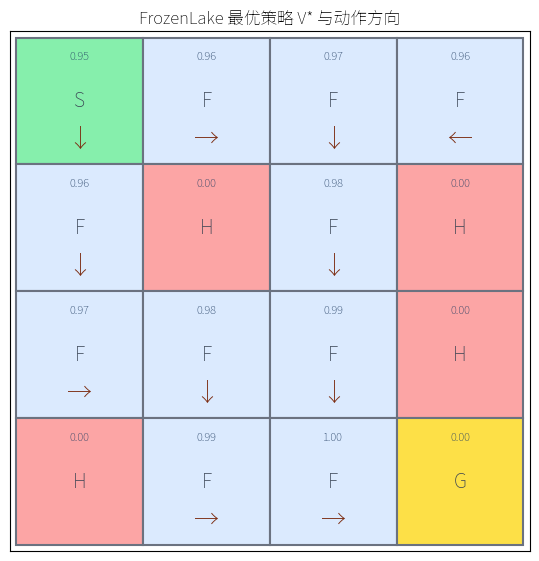

In [5]:
from viz_utils import visualize_frozen_lake
visualize_frozen_lake(V_val, pi_val, title='FrozenLake 最优策略 V* 与动作方向')

## 3.5 小结

- **策略迭代**：评估 ↔ 改进，循环直到稳定
- **值迭代**：直接对 V* 迭代，更快
- DP 要求已知 MDP，现实中不可用——后续章节的 RL 算法都是'在不知道 MDP 时近似 DP'

下一章：**蒙特卡洛方法**——用样本平均估计价值，无需 MDP 模型。